# Week 1 — Penguin Random Forest + SHAP Walkthrough 🐧
### From pandas data handling to a complete machine-learning research workflow

In **Day 2**, you learned how to load, inspect, summarize, and clean a dataset using pandas. Today we use those same skills to complete a full machine-learning workflow.

We will use the **Palmer Penguins** dataset to answer a simple classification question:

> **Can we predict whether a penguin is Adelie or not Adelie using its measurements?**

This notebook is a practice version of what you will later do for the **Heart Disease project**. The code is written in a simple, direct way so that each step can be reused in your final project.

**Workflow:**

`Dataset → Data preparation → Feature engineering → EDA → Model → Evaluation → SHAP → Research interpretation`


## 0. Setup — import the tools

A Colab notebook starts empty. We first import the Python libraries we need.

**Python terms to remember:**

- A **library** is a collection of useful tools.
- `import pandas as pd` loads pandas and gives it the short name `pd`.
- `pd.read_csv()` is a pandas **function** used to load CSV files.
- `df.head()` is a DataFrame **method** because it acts on the DataFrame object `df`.


In [1]:
# Install SHAP if it is not already available in Colab
!pip install shap --quiet

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

import shap


## 1. Research question and objectives

Before coding, we state the research purpose clearly.

**Research question**

> How can a Random Forest model classify Adelie vs non-Adelie penguins, and which features explain the model's predictions?

**Objectives**

1. Describe and prepare the Penguin dataset.
2. Explore the data using EDA plots.
3. Engineer a new feature called `bill_ratio`.
4. Train a Random Forest classifier.
5. Evaluate the model using accuracy, precision, recall, F1-score, and a confusion matrix.
6. Use SHAP to explain global and local model predictions.

**Research paper connection:** These objectives later guide the Introduction, Methodology, Results and Discussion, and Conclusion.


## 2. Load the dataset

The **Palmer Penguins** dataset contains measurements from penguins observed in Antarctica.

Each **row** represents one penguin.
Each **column** represents one variable or feature.


In [2]:
# Load the Palmer Penguins dataset
try:
    df = sns.load_dataset("penguins")
except Exception:
    data_url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv"
    df = pd.read_csv(data_url)

print("Dataset loaded successfully.")
df.head()


Dataset loaded successfully.


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


## 3. Dataset description

This is the kind of information you will later write in the **Methodology** section.

We need to know:

- number of rows;
- number of columns;
- column names;
- numerical columns;
- categorical columns;
- the target variable we want to predict.


In [3]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("Column names:")
list(df.columns)


Number of rows: 344
Number of columns: 7
Column names:


['species',
 'island',
 'bill_length_mm',
 'bill_depth_mm',
 'flipper_length_mm',
 'body_mass_g',
 'sex']

In [4]:
# Check column types and missing values
# object = text/category; float64/int64 = numerical columns

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


**Research writing prompt:**

In your paper, you should be able to write a short dataset paragraph like this:

> The Palmer Penguins dataset contains penguin records described by physical measurements such as bill length, bill depth, flipper length, and body mass, as well as categorical variables such as island and sex.


## 4. Data preparation: missing values

Before modeling, we check whether the dataset has missing values.

This supports the **Data Preparation** part of the Methodology section.


In [5]:
# Count missing values in each column
missing_values = df.isnull().sum()
missing_values


,0
species,0
island,0
bill_length_mm,2
bill_depth_mm,2
flipper_length_mm,2
body_mass_g,2
sex,11


In [6]:
# Remove rows with missing values and reset the row numbers
# We save the cleaned dataset as df_clean first, so we can see the change.

df_clean = df.dropna().reset_index(drop=True)

print("Original rows:", df.shape[0])
print("Rows after cleaning:", df_clean.shape[0])


Original rows: 344
Rows after cleaning: 333


In [7]:
# From this point onward, we use the cleaned dataset

df = df_clean.copy()
df.head()


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
4,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


**Research writing prompt:**

> Rows with missing values were removed before modeling, leaving a cleaned dataset for analysis.

Remember: data cleaning is not only a coding step. It changes the dataset used for EDA, modeling, and SHAP.


## 5. Create the target variable

The original dataset has three species: Adelie, Chinstrap, and Gentoo.

For this practice project, we turn the problem into a **binary classification** task:

- `1` = Adelie
- `0` = Not Adelie

The target variable is the answer the model tries to predict.


In [8]:
# Create the binary target variable

df["is_adelie"] = (df["species"] == "Adelie").astype(int)

df[["species", "is_adelie"]].head(10)


,species,is_adelie
0,Adelie,1
1,Adelie,1
2,Adelie,1
3,Adelie,1
4,Adelie,1
5,Adelie,1
6,Adelie,1
7,Adelie,1
8,Adelie,1
9,Adelie,1


In [9]:
# Create a readable label for plots

df["target_label"] = df["is_adelie"].map({1: "Adelie", 0: "Not Adelie"})

df["target_label"].value_counts()


,count
target_label,
Not Adelie,187
Adelie,146


**Research writing prompt:**

> The species column was converted into a binary target variable, where Adelie penguins were coded as 1 and non-Adelie penguins were coded as 0.


## 6. Feature engineering: create `bill_ratio`

**Feature engineering** means creating a new useful variable from existing variables.

Here, we create:

`bill_ratio = bill_length_mm / bill_depth_mm`

This feature represents the **shape** of the bill, not only the size.


In [10]:
# Create an engineered feature

df["bill_ratio"] = df["bill_length_mm"] / df["bill_depth_mm"]

df[["bill_length_mm", "bill_depth_mm", "bill_ratio"]].head()


,bill_length_mm,bill_depth_mm,bill_ratio
0,39.1,18.7,2.090909
1,39.5,17.4,2.270115
2,40.3,18.0,2.238889
3,36.7,19.3,1.901554
4,39.3,20.6,1.907767


**Research paper connection:**

- In **Methodology**, explain how `bill_ratio` was created.
- In **Results and Discussion**, discuss whether the feature appeared useful in EDA or SHAP.


# 7. Exploratory Data Analysis (EDA)

EDA helps us understand the data before training the model.

For a classification project, EDA should do **two things**:

1. Study the **input features by themselves**.
2. Compare the **input features against the target variable**.

This matters because the model will use the input features to predict the target. We first ask, “What do the features look like?” Then we ask, “Which features seem to separate the classes?”

**Research paper connection:** EDA outputs usually appear in the **Results and Discussion** section, where you report each plot and explain what it means.


## 7.1 Set the numerical input features

These are the numerical input features we will examine in EDA.

The target variable `is_adelie` is **not** an input feature. It is the label the model is trying to predict.

We will also create two helper lists:

- `feature_titles`: cleaner names for plot titles.
- `feature_xlabels`: cleaner names for x-axis labels.

These lists make the loop plots easier to read.

In [11]:
numeric_input_features = [
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g",
    "bill_ratio"
]

feature_titles = [
    "Bill Length",
    "Bill Depth",
    "Flipper Length",
    "Body Mass",
    "Bill Ratio"
]

feature_xlabels = [
    "Bill length (mm)",
    "Bill depth (mm)",
    "Flipper length (mm)",
    "Body mass (g)",
    "Bill ratio"
]

numeric_input_features

['bill_length_mm',
 'bill_depth_mm',
 'flipper_length_mm',
 'body_mass_g',
 'bill_ratio']

## 7.2 Target distribution: class balance

Before studying the input features, check the target variable.

This plot shows how many observations are in each class.

**Why it matters:** Class balance affects how we interpret accuracy, precision, recall, and F1-score.


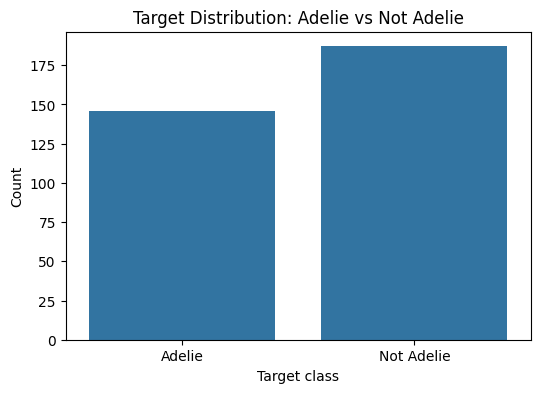

In [12]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="target_label")
plt.title("Target Distribution: Adelie vs Not Adelie")
plt.xlabel("Target class")
plt.ylabel("Count")
plt.show()


**Research writing prompt:**

What does this plot show about class balance? Is one class much larger than the other?


## 7.3 One manual histogram example

Before using a loop, let us make **one histogram manually**.

This shows the basic idea: choose one input feature, plot its distribution, and add a title and axis labels.

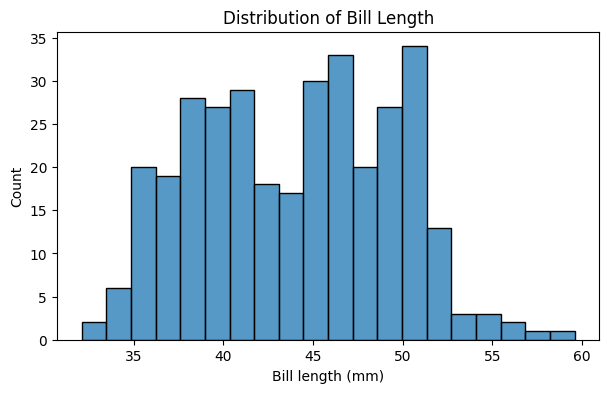

In [13]:
plt.figure(figsize=(7, 4))
sns.histplot(data=df, x="bill_length_mm", bins=20)
plt.title("Distribution of Bill Length")
plt.xlabel("Bill length (mm)")
plt.ylabel("Count")
plt.show()

**Teaching note:**

The code above creates one plot for one feature. However, the project has several numerical input features. Instead of writing almost the same code five times, we can use a small `for` loop to repeat the same plotting pattern.

## 7.4 Overall distributions of all input features

Now we use a loop to plot all numerical input features in one figure.

These plots answer:

> What do the input features look like overall before comparing classes?

The loop is only used to save space. It repeats the same histogram command for each feature in the list.

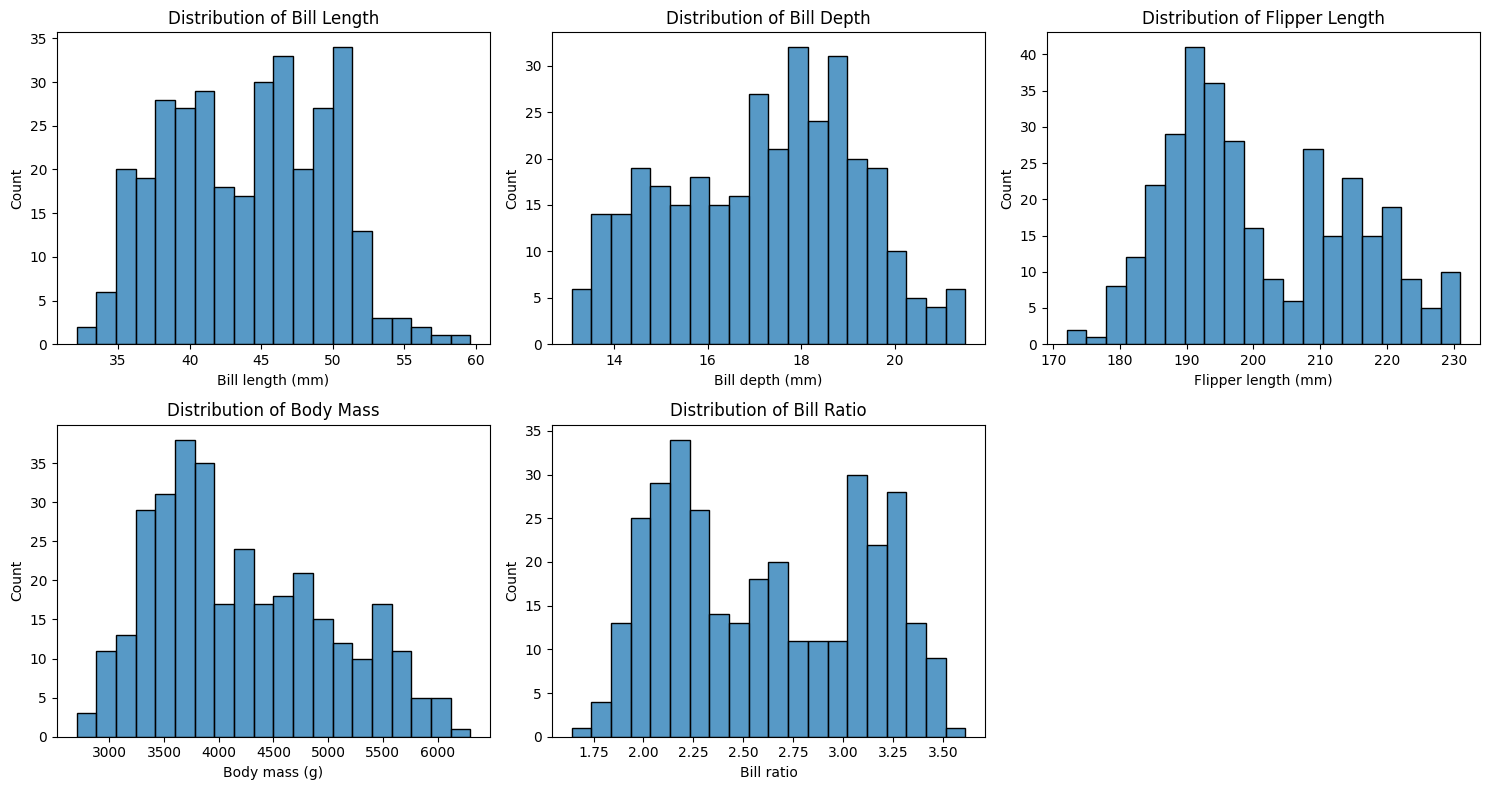

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i in range(len(numeric_input_features)):
    sns.histplot(
        data=df,
        x=numeric_input_features[i],
        bins=20,
        ax=axes[i]
    )
    axes[i].set_title(f"Distribution of {feature_titles[i]}")
    axes[i].set_xlabel(feature_xlabels[i])
    axes[i].set_ylabel("Count")

# Hide the empty sixth plot space because we only have five features.
axes[5].set_visible(False)

plt.tight_layout()
plt.show()

**How the loop works:**

- `numeric_input_features` stores the column names we want to plot.
- `plt.subplots(2, 3)` creates a 2-row by 3-column plot area.
- `axes[i]` tells Python which plot space to use.
- `for i in range(len(numeric_input_features))` repeats the plotting code once for each input feature.
- `axes[5].set_visible(False)` hides the empty plot because there are five features but six spaces.

**Research writing prompt:**

What do the overall feature distributions show about the range, spread, and shape of the input features? Do any features appear to have multiple groups or possible outliers?

## 7.5 Input feature distributions by target class

The previous plots showed each feature overall. Now we compare the distribution of each feature for **Adelie** and **Not Adelie** penguins.

These plots answer:

> Does the feature distribution look different for the two target classes?

This is more directly connected to classification because the model is trying to separate these two classes.

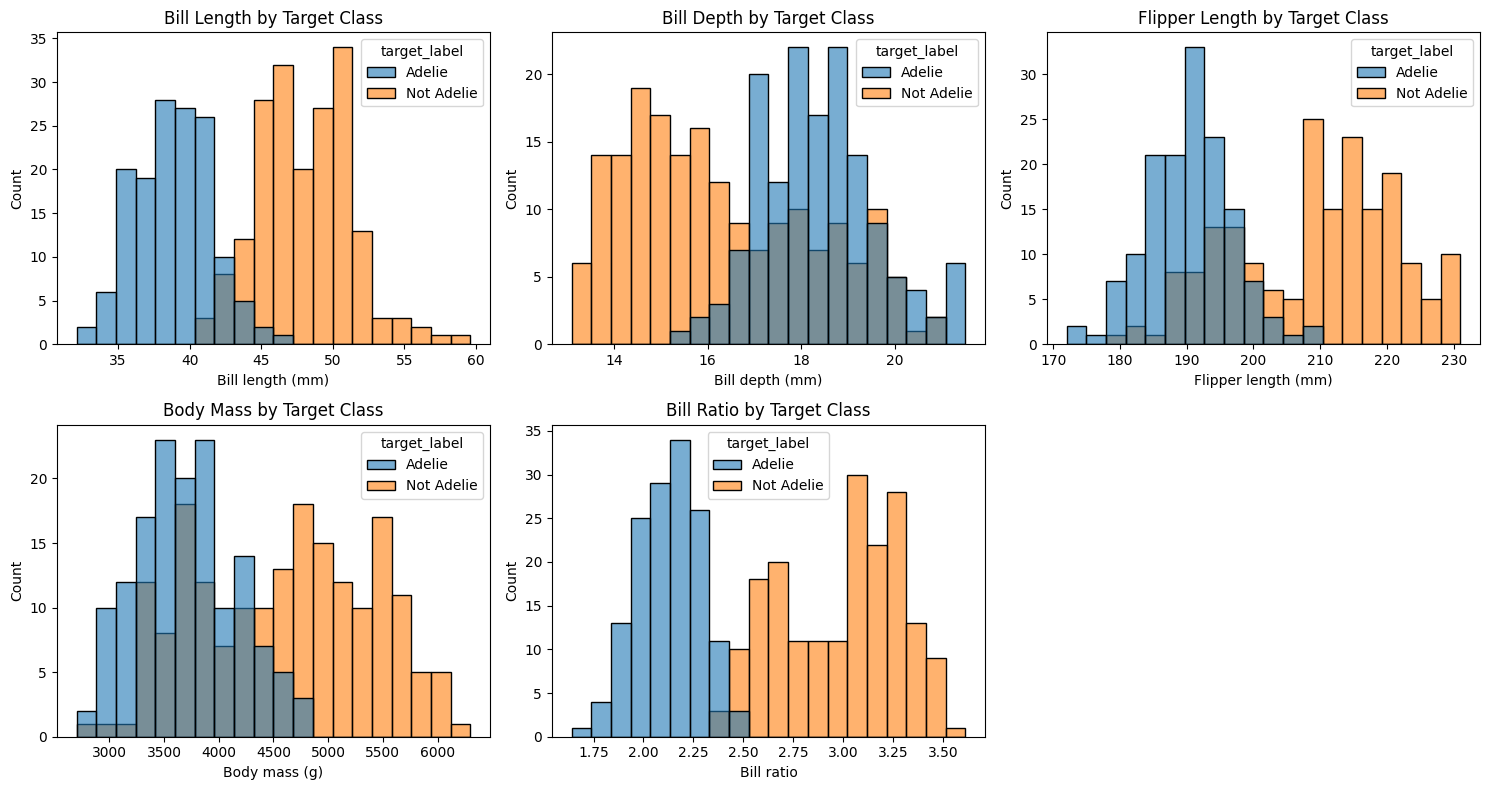

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i in range(len(numeric_input_features)):
    sns.histplot(
        data=df,
        x=numeric_input_features[i],
        hue="target_label",
        bins=20,
        alpha=0.6,
        ax=axes[i]
    )
    axes[i].set_title(f"{feature_titles[i]} by Target Class")
    axes[i].set_xlabel(feature_xlabels[i])
    axes[i].set_ylabel("Count")

# Hide the empty sixth plot space because we only have five features.
axes[5].set_visible(False)

plt.tight_layout()
plt.show()

**Research writing prompt:**

Which input features show the clearest difference between Adelie and Not Adelie penguins? Which features show more overlap between the two classes?

## 7.6 Box plots of input features by target class

Histograms show the shape of each distribution. Box plots summarize each feature by class using the median, spread, and possible outliers.

These plots answer:

> Which features appear to separate the two classes most clearly?

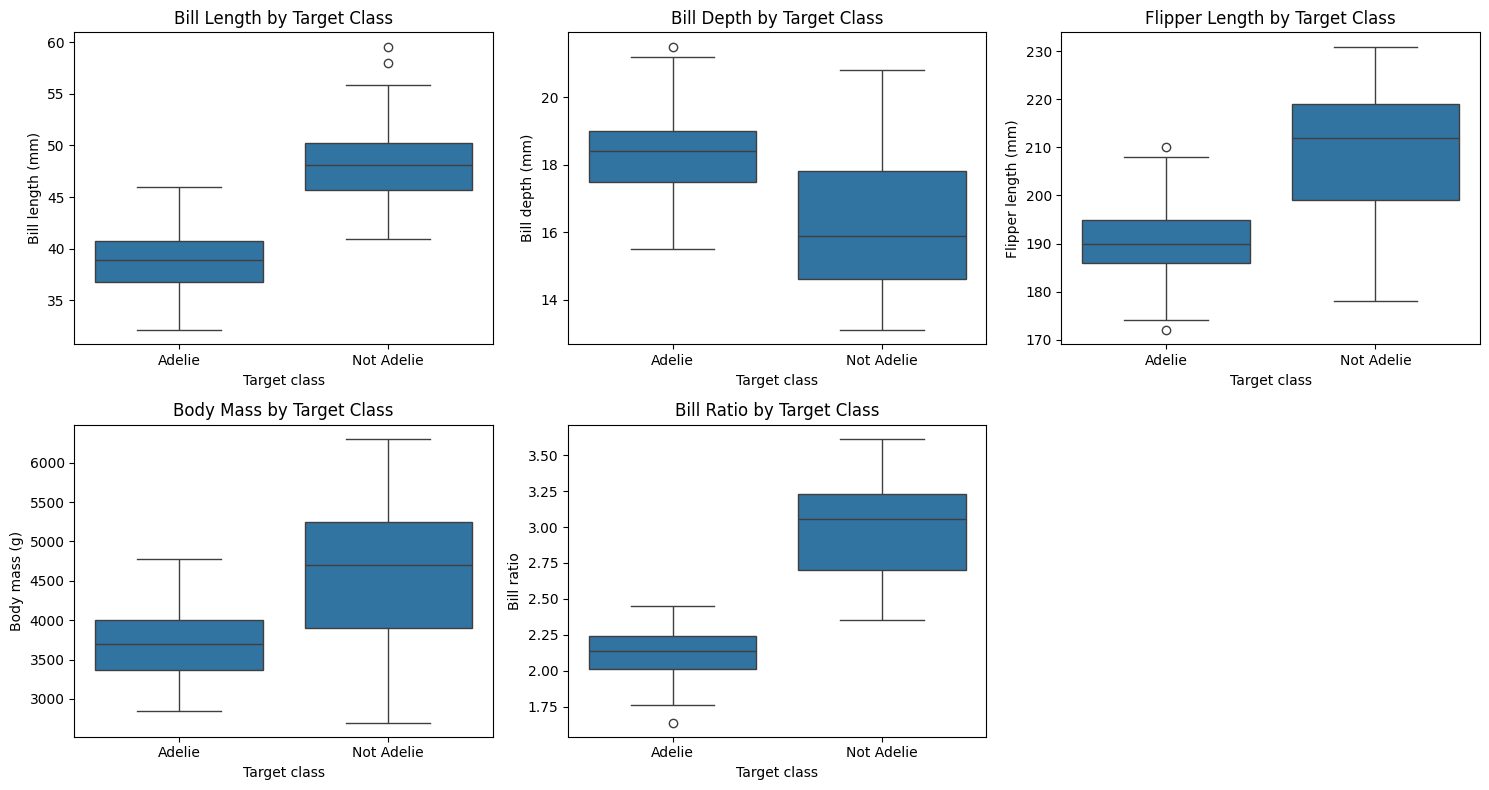

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i in range(len(numeric_input_features)):
    sns.boxplot(
        data=df,
        x="target_label",
        y=numeric_input_features[i],
        ax=axes[i]
    )
    axes[i].set_title(f"{feature_titles[i]} by Target Class")
    axes[i].set_xlabel("Target class")
    axes[i].set_ylabel(feature_xlabels[i])

# Hide the empty sixth plot space because we only have five features.
axes[5].set_visible(False)

plt.tight_layout()
plt.show()

**Research writing prompt:**

Based on the box plots, which features have the strongest class separation? Which features have more overlap? These observations should later be compared with the Random Forest and SHAP results.

## 7.7 Two input features vs target: bill length and bill depth

A scatter plot helps us see whether two input features separate the classes better together than alone.

Each point is one penguin. The color shows the target class.


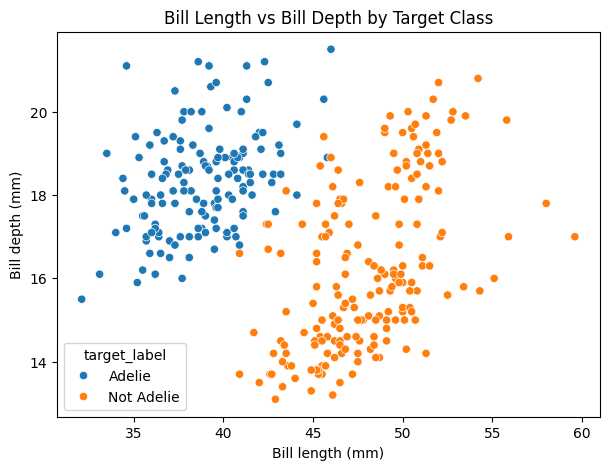

In [17]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x="bill_length_mm", y="bill_depth_mm", hue="target_label")
plt.title("Bill Length vs Bill Depth by Target Class")
plt.xlabel("Bill length (mm)")
plt.ylabel("Bill depth (mm)")
plt.show()


**Research writing prompt:**

Do the two classes form visible clusters? Which combination of features seems useful for classification?


## 7.8 Two input features vs target: flipper length and body mass

This second scatter plot checks another pair of input features.

The goal is to see whether feature combinations create visible separation between Adelie and non-Adelie penguins.


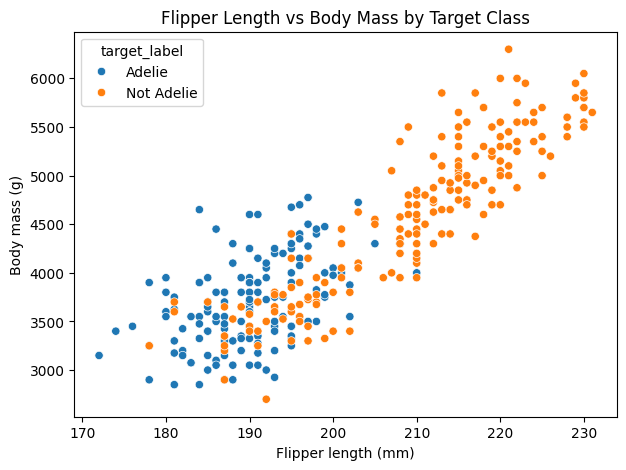

In [18]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x="flipper_length_mm", y="body_mass_g", hue="target_label")
plt.title("Flipper Length vs Body Mass by Target Class")
plt.xlabel("Flipper length (mm)")
plt.ylabel("Body mass (g)")
plt.show()


**Research writing prompt:**

Do flipper length and body mass together separate the classes clearly, partly, or weakly?


## 7.9 Correlation heatmap of input features

A correlation heatmap shows how numerical input features are related to one another.

Values close to `+1` mean two features increase together. Values close to `-1` mean one increases as the other decreases. Values close to `0` mean weak linear relationship.

Here, we focus on the **input features**. The target variable is not included because it is the label, not an input feature.


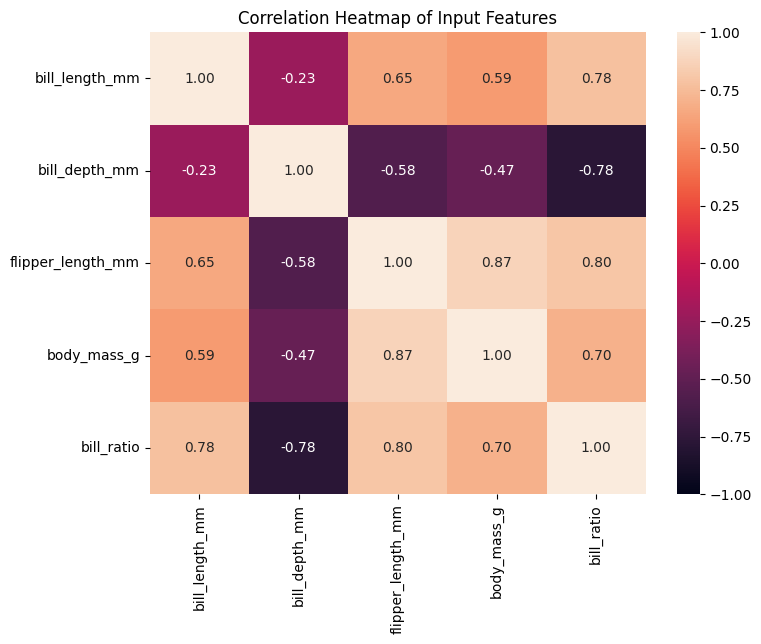

In [19]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_input_features].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f")
plt.title("Correlation Heatmap of Input Features")
plt.show()


**Research writing prompt:**

Which input features are strongly related to each other? Could highly related features give the model similar information?

**Careful:** Correlation shows association, not causation.


## 7.10 EDA summary: what should we carry into modeling?

After EDA, summarize what you learned before training the model.

A strong EDA summary should answer:

1. What did the input features look like overall?
2. How did the feature distributions differ between Adelie and Not Adelie penguins?
3. Which box plots showed the clearest class separation?
4. Did any feature combinations create clearer separation?
5. Which patterns should be compared later with SHAP?

**Key idea:** EDA shows visible patterns in the data. SHAP later shows which patterns the trained model actually used.

# 8. Prepare `X` and `y`

Machine learning models need:

- `X`: the input features used to make predictions;
- `y`: the target label the model is trying to predict.

For this model, we use numerical features and also include `island` and `sex` after one-hot encoding.


In [20]:
# Select input features

numeric_model_features = [
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g",
    "bill_ratio"
]

categorical_model_features = ["island", "sex"]

X_raw = df[numeric_model_features + categorical_model_features]
y = df["is_adelie"]

X_raw.head()


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,bill_ratio,island,sex
0,39.1,18.7,181.0,3750.0,2.090909,Torgersen,Male
1,39.5,17.4,186.0,3800.0,2.270115,Torgersen,Female
2,40.3,18.0,195.0,3250.0,2.238889,Torgersen,Female
3,36.7,19.3,193.0,3450.0,1.901554,Torgersen,Female
4,39.3,20.6,190.0,3650.0,1.907767,Torgersen,Male


## One-hot encoding

Models need numbers, not text.

`pd.get_dummies()` converts categorical columns such as `island` and `sex` into numerical 0/1 columns.


In [21]:
X = pd.get_dummies(X_raw, columns=categorical_model_features, drop_first=True)

X.head()


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,bill_ratio,island_Dream,island_Torgersen,sex_Male
0,39.1,18.7,181.0,3750.0,2.090909,False,True,True
1,39.5,17.4,186.0,3800.0,2.270115,False,True,False
2,40.3,18.0,195.0,3250.0,2.238889,False,True,False
3,36.7,19.3,193.0,3450.0,1.901554,False,True,False
4,39.3,20.6,190.0,3650.0,1.907767,False,True,True


In [22]:
print("Number of input features:", X.shape[1])
print("Feature names:")
list(X.columns)


Number of input features: 8
Feature names:


['bill_length_mm',
 'bill_depth_mm',
 'flipper_length_mm',
 'body_mass_g',
 'bill_ratio',
 'island_Dream',
 'island_Torgersen',
 'sex_Male']

**Research writing prompt:**

In the Methodology section, explain what your input features were and what your target variable was.


# 9. Train-test split

We split the data into two parts:

- **Training set:** used to teach the model.
- **Test set:** used to evaluate the model on unseen data.

This helps us check whether the model learned a general pattern instead of simply memorizing the training data.


In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])


Training rows: 249
Testing rows: 84


# 10. Train the Random Forest model

A **Random Forest** is a machine-learning model made of many decision trees.

Each tree makes a prediction, and the forest combines their votes.

Important model settings:

- `n_estimators=200`: the forest uses 200 trees.
- `random_state=42`: makes the result reproducible.

**Research paper connection:** This information belongs in the Methodology section under model development.


In [24]:
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

print("Random Forest model trained successfully.")


Random Forest model trained successfully.


In [25]:
# Use the trained model to predict the target for the test set

y_pred = model.predict(X_test)

print("Predictions completed.")


Predictions completed.


# 11. Model evaluation

Now we evaluate the model using the test set.

We will report:

- accuracy;
- precision;
- recall;
- F1-score;
- an actual-vs-predicted results table;
- confusion matrix;
- classification report.

These outputs belong in the **Results and Discussion** section of the paper.

In [26]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Score": [accuracy, precision, recall, f1]
})

metrics_df["Score"] = metrics_df["Score"].round(3)
metrics_df


,Metric,Score
0,Accuracy,0.988
1,Precision,0.974
2,Recall,1.000
3,F1-score,0.987


**How to interpret these metrics:**

- **Accuracy:** overall share of correct predictions.
- **Precision:** when the model predicts Adelie, how often it is correct.
- **Recall:** out of all real Adelie penguins, how many the model finds.
- **F1-score:** balances precision and recall.

**Research writing prompt:**

Do not only say “the model performed well.” Report the actual values and explain what they mean.


## 11.1 Actual vs predicted test cases

The metrics give a summary of model performance, but we also want to inspect individual test cases.

This section shows:

- the input features from `X_test`;
- the actual target value from `y_test`;
- the model prediction from `y_pred`;
- whether the prediction was correct or wrong;
- the model's estimated probability that the penguin is Adelie;
- the model's confidence in its predicted class.

This helps us understand not only how many predictions were correct, but also **where the model was right, where it was wrong, and where it was least confident**.

In [27]:
# Create a table that compares the test features, actual labels, and predicted labels

prediction_results = X_test.copy().reset_index(drop=True)

# Add the actual and predicted y-values
prediction_results["Actual_y"] = y_test.reset_index(drop=True)
prediction_results["Predicted_y"] = y_pred

# Add the model's probability for the Adelie class
adelie_class_index = list(model.classes_).index(1)
prediction_results["Probability_Adelie"] = model.predict_proba(X_test)[:, adelie_class_index]
prediction_results["Probability_Adelie"] = prediction_results["Probability_Adelie"].round(3)

# Convert 0 and 1 into readable class names
class_names = {
    0: "Not Adelie",
    1: "Adelie"
}

prediction_results["Actual_class"] = prediction_results["Actual_y"].map(class_names)
prediction_results["Predicted_class"] = prediction_results["Predicted_y"].map(class_names)

# Check whether each prediction was correct
prediction_results["Prediction_result"] = np.where(
    prediction_results["Actual_y"] == prediction_results["Predicted_y"],
    "Correct",
    "Wrong"
)

# Model confidence means the probability assigned to the class the model predicted.
# If the model predicted Adelie, confidence = Probability_Adelie.
# If the model predicted Not Adelie, confidence = 1 - Probability_Adelie.
prediction_results["Model_confidence"] = np.where(
    prediction_results["Predicted_y"] == 1,
    prediction_results["Probability_Adelie"],
    1 - prediction_results["Probability_Adelie"]
)
prediction_results["Model_confidence"] = prediction_results["Model_confidence"].round(3)

# Choose the columns we want to display
feature_columns_to_show = list(X_test.columns)
columns_to_show = feature_columns_to_show + [
    "Actual_y",
    "Predicted_y",
    "Actual_class",
    "Predicted_class",
    "Probability_Adelie",
    "Model_confidence",
    "Prediction_result"
]

prediction_results[columns_to_show].head(10)

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,bill_ratio,island_Dream,island_Torgersen,sex_Male,Actual_y,Predicted_y,Actual_class,Predicted_class,Probability_Adelie,Model_confidence,Prediction_result
0,41.3,21.1,195.0,4400.0,1.957346,False,False,True,1,1,Adelie,Adelie,1.000,1.000,Correct
1,36.0,17.8,195.0,3450.0,2.022472,True,False,False,1,1,Adelie,Adelie,0.995,0.995,Correct
2,41.4,18.5,202.0,3875.0,2.237838,False,True,True,1,1,Adelie,Adelie,0.955,0.955,Correct
3,55.1,16.0,230.0,5850.0,3.443750,False,False,True,0,0,Not Adelie,Not Adelie,0.000,1.000,Correct
4,48.5,17.5,191.0,3400.0,2.771429,True,False,True,0,0,Not Adelie,Not Adelie,0.005,0.995,Correct
5,45.7,17.3,193.0,3600.0,2.641618,True,False,False,0,0,Not Adelie,Not Adelie,0.025,0.975,Correct
6,37.8,18.1,193.0,3750.0,2.088398,True,False,True,1,1,Adelie,Adelie,0.995,0.995,Correct
7,45.2,15.8,215.0,5300.0,2.860759,False,False,True,0,0,Not Adelie,Not Adelie,0.000,1.000,Correct
8,50.8,17.3,228.0,5600.0,2.936416,False,False,True,0,0,Not Adelie,Not Adelie,0.020,0.980,Correct
9,36.0,17.1,187.0,3700.0,2.105263,True,False,False,1,1,Adelie,Adelie,0.995,0.995,Correct


**How to read this table:**

Each row is one penguin from the test set. The input feature columns show what the model used to make the prediction. `Actual_y` is the true answer, while `Predicted_y` is the model's answer.

`Probability_Adelie` shows how strongly the model thinks the penguin is Adelie. `Model_confidence` shows how confident the model is in the class it actually predicted. A prediction is marked as `Correct` when the actual and predicted values match.

In [28]:
# Count how many predictions were correct and wrong

prediction_summary = prediction_results["Prediction_result"].value_counts().reindex(
    ["Correct", "Wrong"],
    fill_value=0
).reset_index()

prediction_summary.columns = ["Prediction result", "Number of test penguins"]
prediction_summary

,Prediction result,Number of test penguins
0,Correct,83
1,Wrong,1


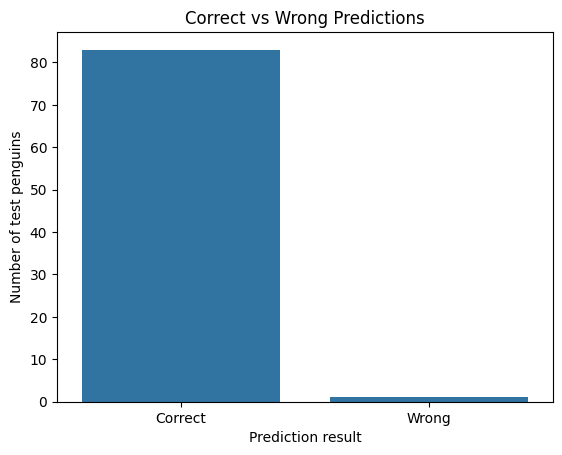

In [29]:
# Plot correct vs wrong predictions

sns.barplot(
    data=prediction_summary,
    x="Prediction result",
    y="Number of test penguins"
)
plt.title("Correct vs Wrong Predictions")
plt.xlabel("Prediction result")
plt.ylabel("Number of test penguins")
plt.show()

### Wrong predictions only

This table is important because it shows the cases where the model failed. Students should inspect these rows and ask:

- What was the actual class?
- What did the model predict?
- Was the model confident or uncertain?
- Do the input features look close to the other class?

In [30]:
# Show only the cases where the model was wrong

wrong_predictions = prediction_results[
    prediction_results["Prediction_result"] == "Wrong"
]

print("Number of wrong predictions:", wrong_predictions.shape[0])

if wrong_predictions.shape[0] == 0:
    print("The model made no wrong predictions in this test set.")
    print("This can happen when the classes are easy to separate or the test set is small.")
    print("In harder datasets, such as Heart Disease, wrong predictions are more likely and must be discussed carefully.")
else:
    display(wrong_predictions[columns_to_show])

Number of wrong predictions: 1


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,bill_ratio,island_Dream,island_Torgersen,sex_Male,Actual_y,Predicted_y,Actual_class,Predicted_class,Probability_Adelie,Model_confidence,Prediction_result
22,45.6,19.4,194.0,3525.0,2.350515,True,False,False,0,1,Not Adelie,Adelie,0.555,0.555,Wrong


### Least confident predictions

Sometimes a model may get the answer correct but still be uncertain. These cases are useful to inspect because they may be close to the decision boundary.

A lower `Model_confidence` means the model was less sure about its prediction.

In [31]:
# Show the predictions where the model was least confident

least_confident_predictions = prediction_results.sort_values(
    by="Model_confidence",
    ascending=True
)

least_confident_predictions[columns_to_show].head(10)

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,bill_ratio,island_Dream,island_Torgersen,sex_Male,Actual_y,Predicted_y,Actual_class,Predicted_class,Probability_Adelie,Model_confidence,Prediction_result
25,42.4,17.3,181.0,3600.0,2.450867,True,False,False,0,0,Not Adelie,Not Adelie,0.470,0.530,Correct
22,45.6,19.4,194.0,3525.0,2.350515,True,False,False,0,1,Not Adelie,Adelie,0.555,0.555,Wrong
56,42.5,17.3,187.0,3350.0,2.456647,True,False,False,0,0,Not Adelie,Not Adelie,0.420,0.580,Correct
66,45.8,18.9,197.0,4150.0,2.423280,False,True,True,1,1,Adelie,Adelie,0.725,0.725,Correct
36,46.0,18.9,195.0,4150.0,2.433862,True,False,False,0,0,Not Adelie,Not Adelie,0.220,0.780,Correct
34,40.7,17.0,190.0,3725.0,2.394118,True,False,True,1,1,Adelie,Adelie,0.795,0.795,Correct
45,44.1,19.7,196.0,4400.0,2.238579,True,False,True,1,1,Adelie,Adelie,0.810,0.810,Correct
63,40.8,18.9,208.0,4300.0,2.158730,True,False,True,1,1,Adelie,Adelie,0.870,0.870,Correct
77,41.0,20.0,203.0,4725.0,2.050000,False,False,True,1,1,Adelie,Adelie,0.875,0.875,Correct
15,32.1,15.5,188.0,3050.0,2.070968,True,False,False,1,1,Adelie,Adelie,0.890,0.890,Correct


### Correct predictions only

This table shows examples where the model predicted correctly. Comparing correct and wrong predictions helps us understand what kinds of cases the model handles well and what kinds of cases may be more difficult.

In [32]:
# Show a few examples where the model was correct

correct_predictions = prediction_results[
    prediction_results["Prediction_result"] == "Correct"
]

print("Number of correct predictions:", correct_predictions.shape[0])
correct_predictions[columns_to_show].head(10)

Number of correct predictions: 83


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,bill_ratio,island_Dream,island_Torgersen,sex_Male,Actual_y,Predicted_y,Actual_class,Predicted_class,Probability_Adelie,Model_confidence,Prediction_result
0,41.3,21.1,195.0,4400.0,1.957346,False,False,True,1,1,Adelie,Adelie,1.000,1.000,Correct
1,36.0,17.8,195.0,3450.0,2.022472,True,False,False,1,1,Adelie,Adelie,0.995,0.995,Correct
2,41.4,18.5,202.0,3875.0,2.237838,False,True,True,1,1,Adelie,Adelie,0.955,0.955,Correct
3,55.1,16.0,230.0,5850.0,3.443750,False,False,True,0,0,Not Adelie,Not Adelie,0.000,1.000,Correct
4,48.5,17.5,191.0,3400.0,2.771429,True,False,True,0,0,Not Adelie,Not Adelie,0.005,0.995,Correct
5,45.7,17.3,193.0,3600.0,2.641618,True,False,False,0,0,Not Adelie,Not Adelie,0.025,0.975,Correct
6,37.8,18.1,193.0,3750.0,2.088398,True,False,True,1,1,Adelie,Adelie,0.995,0.995,Correct
7,45.2,15.8,215.0,5300.0,2.860759,False,False,True,0,0,Not Adelie,Not Adelie,0.000,1.000,Correct
8,50.8,17.3,228.0,5600.0,2.936416,False,False,True,0,0,Not Adelie,Not Adelie,0.020,0.980,Correct
9,36.0,17.1,187.0,3700.0,2.105263,True,False,False,1,1,Adelie,Adelie,0.995,0.995,Correct


**Research writing prompt:**

When discussing model evaluation, do not only report the metric values. Also explain what the model got right, what it got wrong, and whether the wrong or uncertain cases have feature values that make them difficult to classify. For the Heart Disease project, this type of table can help identify false positives and false negatives more clearly.

## 11.2 Confusion matrix

The confusion matrix shows how the model was right and how it was wrong.

For a binary classification problem, it shows:

- true negatives;
- false positives;
- false negatives;
- true positives.


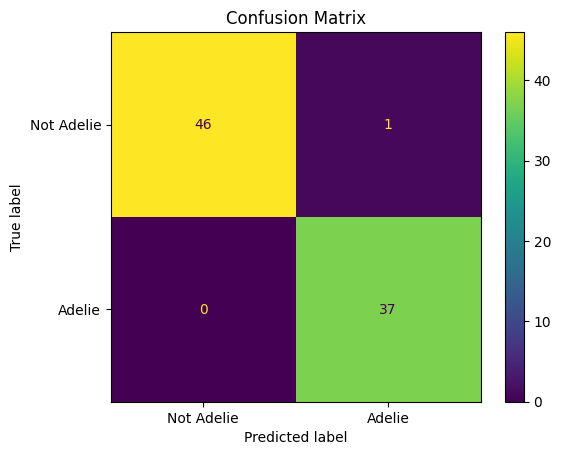

In [33]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Not Adelie", "Adelie"]
)
plt.title("Confusion Matrix")
plt.show()


**Research writing prompt:**

What type of error did the model make? Were there false positives or false negatives? In the Heart Disease project, false negatives may be especially important because they may represent missed disease cases.


## 11.3 Classification report

The classification report gives precision, recall, and F1-score for each class.


In [34]:
print(classification_report(y_test, y_pred, target_names=["Not Adelie", "Adelie"]))


              precision    recall  f1-score   support

  Not Adelie       1.00      0.98      0.99        47
      Adelie       0.97      1.00      0.99        37

    accuracy                           0.99        84
   macro avg       0.99      0.99      0.99        84
weighted avg       0.99      0.99      0.99        84



# 12. Explain the model with SHAP

The model can predict, but we also want to explain **why** it predicts.

**SHAP** helps explain which features pushed the model toward or away from a prediction.

Important limitation:

> SHAP explains the model's behavior. It does not prove real-world causation.

**Research paper connection:** SHAP belongs in both Methodology and Results/Discussion.


In [35]:
# Create a SHAP explainer for the trained Random Forest model

explainer = shap.TreeExplainer(model)
explanation = explainer(X_test)

# For binary classification, SHAP may return values for both classes.
# We select the explanation for the positive class: Adelie = 1.

if explanation.values.ndim == 3:
    shap_adelie = explanation[:, :, 1]
else:
    shap_adelie = explanation

print("SHAP values calculated for the test set.")


SHAP values calculated for the test set.


## 12.1 SHAP global feature importance

The SHAP bar plot ranks features by their overall importance across the test set.

**Question:** Which features influenced the model most overall?


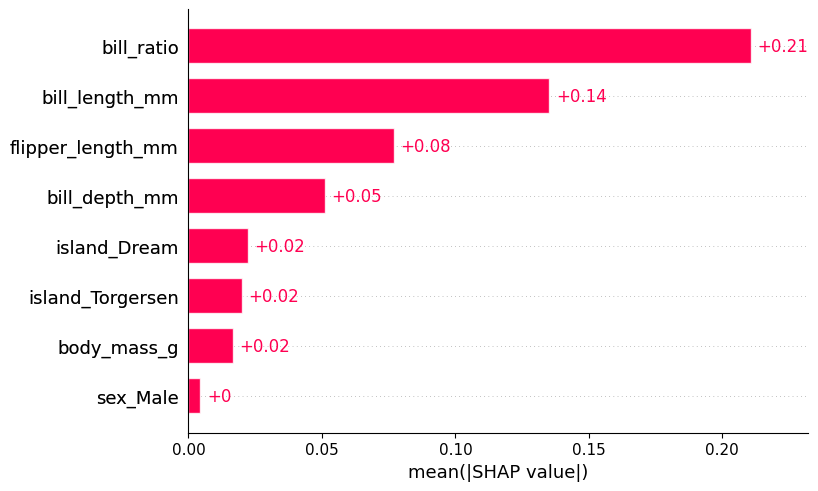

In [36]:
shap.plots.bar(shap_adelie)


**Research writing prompt:**

Which features were most important? Do these features make sense based on the EDA plots?


## 12.2 SHAP beeswarm plot

The beeswarm plot gives more detail than the bar plot.

- Each dot is one penguin.
- The horizontal position shows whether the feature pushed the prediction toward or away from Adelie.
- The color shows whether the feature value was high or low.


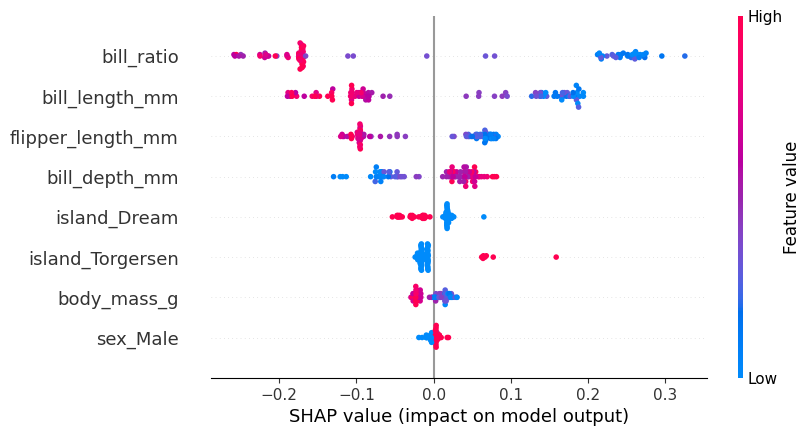

In [37]:
shap.plots.beeswarm(shap_adelie)


**Research writing prompt:**

Do the SHAP patterns agree with the EDA plots? If EDA and SHAP agree, the model is easier to interpret.


## 12.3 SHAP local explanation: one prediction

Global SHAP explains the overall model.

Local SHAP explains **one specific prediction**.

We choose one test penguin and explain why the model gave its prediction.


In [38]:
# Choose one test example to explain
# Try changing i to another number between 0 and len(X_test)-1.

i = 0

actual_label = "Adelie" if y_test.iloc[i] == 1 else "Not Adelie"
predicted_label = "Adelie" if y_pred[i] == 1 else "Not Adelie"
prob_adelie = model.predict_proba(X_test.iloc[[i]])[0][1]

print("Example number:", i)
print("Actual class:", actual_label)
print("Predicted class:", predicted_label)
print("Model probability of Adelie:", round(prob_adelie, 3))


Example number: 0
Actual class: Adelie
Predicted class: Adelie
Model probability of Adelie: 1.0


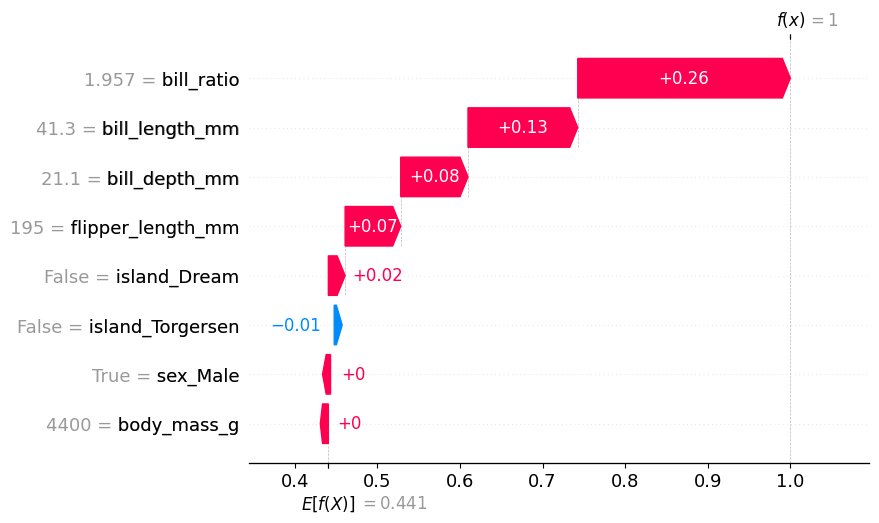

In [39]:
shap.plots.waterfall(shap_adelie[i])


**Research writing prompt:**

Which features pushed this individual prediction toward Adelie? Which features pushed it away? How would you explain this prediction in plain language?


# 13. Connect results to research objectives

Now connect the outputs back to the objectives.

| Objective | Notebook evidence |
|---|---|
| Describe and prepare the dataset | Dataset shape, missing values, cleaned dataset |
| Explore the dataset | Class distribution, histograms, box plot, scatter plot, heatmap |
| Engineer a useful feature | `bill_ratio` |
| Train a classifier | Random Forest model |
| Evaluate model performance | Accuracy, precision, recall, F1-score, confusion matrix |
| Explain model predictions | SHAP bar plot, beeswarm plot, waterfall plot |

**Research writing reminder:**

In Results and Discussion, report each output and then explain what it means.


# 14. Notebook output → paper section map

Use this map when writing the Penguin practice paper and later the Heart Disease paper.

| Notebook output | Paper section |
|---|---|
| Dataset source, rows, columns, features, target | Methodology |
| Missing values and cleaning | Methodology |
| Feature engineering | Methodology and Results/Discussion |
| EDA plots | Results and Discussion |
| Random Forest setup | Methodology |
| Train-test split | Methodology |
| Accuracy, precision, recall, F1-score | Results and Discussion |
| Confusion matrix | Results and Discussion |
| SHAP global plot | Results and Discussion |
| SHAP local waterfall | Results and Discussion |
| Overall interpretation | Conclusion |

**Key idea:** The notebook produces the evidence. The research paper explains the evidence.


# 15. Bridge to the Heart Disease project

You have now completed the full practice workflow:

`Dataset → Data preparation → Feature engineering → EDA → Model → Evaluation → SHAP → Research interpretation`

In the Heart Disease project, you will repeat the same logic with a different dataset and a higher-stakes question.

Remember:

- Do not only run the code.
- Understand what each output means.
- Connect each result to the research objectives.
- Use SHAP carefully: it explains the model, not real-world causation.
